**Image Classification Using Convolution Neural Network (CNN)**

In [15]:
#%pip install seaborn

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as sm

In [17]:
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Conv2D, Dropout, MaxPooling2D, Flatten

In [18]:
from keras.datasets import cifar10
(X_train, y_train), (X_test,ytest) = cifar10.load_data()

In [19]:
X_train, y_train

(array([[[[ 59,  62,  63],
          [ 43,  46,  45],
          [ 50,  48,  43],
          ...,
          [158, 132, 108],
          [152, 125, 102],
          [148, 124, 103]],
 
         [[ 16,  20,  20],
          [  0,   0,   0],
          [ 18,   8,   0],
          ...,
          [123,  88,  55],
          [119,  83,  50],
          [122,  87,  57]],
 
         [[ 25,  24,  21],
          [ 16,   7,   0],
          [ 49,  27,   8],
          ...,
          [118,  84,  50],
          [120,  84,  50],
          [109,  73,  42]],
 
         ...,
 
         [[208, 170,  96],
          [201, 153,  34],
          [198, 161,  26],
          ...,
          [160, 133,  70],
          [ 56,  31,   7],
          [ 53,  34,  20]],
 
         [[180, 139,  96],
          [173, 123,  42],
          [186, 144,  30],
          ...,
          [184, 148,  94],
          [ 97,  62,  34],
          [ 83,  53,  34]],
 
         [[177, 144, 116],
          [168, 129,  94],
          [179, 142,  87],
   

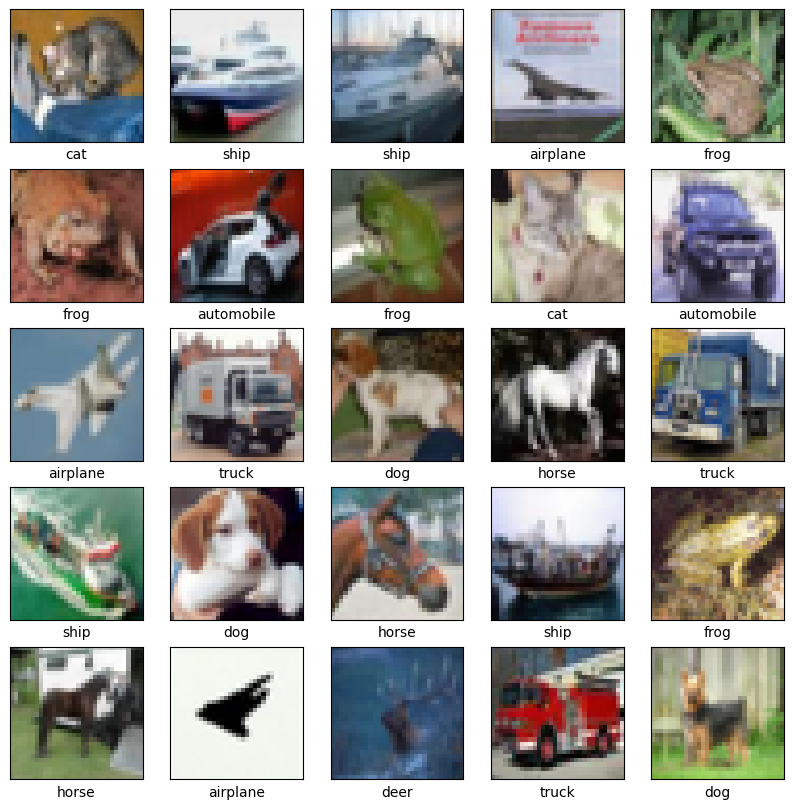

In [20]:
plt.figure(figsize=(10,10))
for i in range (25):
    plt.subplot(5,5,i+1)
    classNames = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog','horse', 'ship', 'truck']
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test[i])
    plt.xlabel(classNames[ytest[i][0]])
plt.show()

In [21]:
# converting input image data into float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [22]:
X_train = (X_train-X_train.mean())/X_train.max()
X_test = (X_test-X_test.mean())/X_test.max()
y_train = keras.utils.to_categorical(y_train, 10)
y_test= keras.utils.to_categorical(ytest, 10)

In [23]:
# Difference between ytest and y_test
print(ytest)
print(y_test)

[[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [24]:
List = [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
print(List)

[(50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 10), (10000, 10)]


In [25]:
model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,794 (4.08 MB)

 Trainable params: 1,070,794 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=1.0e-4), metrics = ['accuracy'])

In [ ]:
model.fit(X_train, y_train, batch_size=256, epochs=200)

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 30s 134ms/step - accuracy: 0.3020 - loss: 1.9538
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.4152 - loss: 1.6487
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.4594 - loss: 1.5235
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 29s 148ms/step - accuracy: 0.4878 - loss: 1.4427
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 31s 158ms/step - accuracy: 0.5087 - loss: 1.3798
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - accuracy: 0.5272 - loss: 1.3278
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - accuracy: 0.5432 - loss: 1.2896
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 169ms/step - accuracy: 0.5571 - loss: 1.2541
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 31s 158ms/step - accuracy: 0.5667 - loss: 1.2252
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 137ms/step - accuracy: 0.5785 - loss: 1.1952
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 0.5831 - loss: 1.1730
Epoch 12

In [ ]:
yhat = np.argmax(model.predict(X_test), axis=1)
print(sm.classification_report(ytest, yhat))
print(f'Accuracy of test data:{sm.accuracy_score(ytest, yhat)*100}%')

In [ ]:
cm = sm.confusion_matrix(ytest, yhat)

plt.clf()
plt.imshow(cm, cmap=plt.cm.autumn_r)

plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=90)
plt.yticks(tick_marks, classNames)

for i in range(len(classNames)):
    for j in range(len(classNames)):
        plt.text(i, j, cm[i][j])

plt.show()